In [1]:
# Section 0 - Install required libraries
# Run this cell first every session prior to anything else

import subprocess
import sys

packages = [
    "pystac-client",
    "planetary-computer",
    "odc-stac",
    "rioxarray",
    "geopandas",
    "matplotlib",
    "numpy",
    "pandas",
    "scikit-learn",
    "shapely",
    "pyproj",
    "tqdm"
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

print("All libraries installed successfully")

All libraries installed successfully


## Section 0 — Imports and configuration

This cell imports all libraries used throughout the pipeline. 
Run this after the install cell at the start of every session.

In [2]:
# Core data libraries
import numpy as np
import pandas as pd
import geopandas as gpd

# Satellite data access
import pystac_client
import planetary_computer

# Raster / geospatial
import rioxarray as rxr
from odc.stac import load as odc_load

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Utilities
import os
import warnings
from tqdm import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')

print("All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"GeoPandas version: {gpd.__version__}")

All imports successful!
NumPy version: 2.4.4
Pandas version: 3.0.2
GeoPandas version: 1.1.3


In [3]:
# Section 0 - Configuration
# All paths and settings for the pipeline - alter these if needed 

# Base path to the challenge data
BASE_PATH = Path("/home/jovyan/work/_User-Persistent-Storage_CephBlock_/f3i-dc-2-sbosm")
DATA_PATH = BASE_PATH / "data"

# Output folders (we'll save maps and charts here)
OUTPUT_PATH = BASE_PATH / "outputs"
MAPS_PATH = OUTPUT_PATH / "stress_maps"
TIMESERIES_PATH = OUTPUT_PATH / "time_series"

# Create output folders if they don't exist
for folder in [OUTPUT_PATH, MAPS_PATH, TIMESERIES_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

# All 6 site boundary files
SITE_FILES = {
    "fresno":     DATA_PATH / "fresno_site_1.geojson",
    "kern":       DATA_PATH / "kern_site_1.geojson",
    "kings":      DATA_PATH / "kings_site_1.geojson",
    "partner":    DATA_PATH / "partner_site_1.geojson",
    "stanislaus": DATA_PATH / "stanislaus_site_1.geojson",
    "tulare":     DATA_PATH / "tulare_site_1.geojson",
}

# Sentinel-2 query settings
CLOUD_THRESHOLD = 20        # max % cloud cover per image
START_DATE = "2019-01-01"   # 6 years of data
END_DATE   = "2024-12-31"

# Growing season months (peak canopy in Central Valley)
PEAK_SEASON_MONTHS = [6, 7, 8]  # June, July, August

# Stress detection threshold
STRESS_ZSCORE_THRESHOLD = -1.0  # pixels below this = underperforming

print("Configuration loaded!")
print(f"Data path: {DATA_PATH}")
print(f"Sites configured: {list(SITE_FILES.keys())}")
print(f"Date range: {START_DATE} to {END_DATE}")

# Verify all site files exist
print("\nVerifying site files:")
for name, path in SITE_FILES.items():
    status = "✓" if path.exists() else "✗ MISSING"
    print(f"  {status} {name}: {path.name}")

Configuration loaded!
Data path: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/f3i-dc-2-sbosm/data
Sites configured: ['fresno', 'kern', 'kings', 'partner', 'stanislaus', 'tulare']
Date range: 2019-01-01 to 2024-12-31

Verifying site files:
  ✓ fresno: fresno_site_1.geojson
  ✓ kern: kern_site_1.geojson
  ✓ kings: kings_site_1.geojson
  ✓ partner: partner_site_1.geojson
  ✓ stanislaus: stanislaus_site_1.geojson
  ✓ tulare: tulare_site_1.geojson


## Section 1 - Load site boundaries

We load all 6 orchard boundary files (GeoJSON format) into GeoPandas.
Each file defines a region of interest (ROI) for one orchard site.
We extract the bounding box of each site to use for satellite imagery queries. 

In [4]:
# Section 1 — Load all site boundaries

def load_site(site_name):
    """Load a GeoJSON site boundary and return key spatial info."""
    path = SITE_FILES[site_name]
    gdf = gpd.read_file(path)
    
    # Ensure consistent coordinate system (WGS84 = standard GPS lat/lon)
    gdf = gdf.to_crs("EPSG:4326")
    
    # Get bounding box [min_lon, min_lat, max_lon, max_lat]
    bbox = gdf.total_bounds
    
    return {
        "name": site_name,
        "gdf": gdf,
        "bbox": bbox,
        "bbox_str": f"{bbox[0]:.4f}, {bbox[1]:.4f}, {bbox[2]:.4f}, {bbox[3]:.4f}"
    }

# Load all 6 sites
print("Loading all site boundaries...\n")
sites = {}
for site_name in SITE_FILES.keys():
    sites[site_name] = load_site(site_name)
    s = sites[site_name]
    print(f"{site_name:12} | bbox: {s['bbox_str']}")

print(f"\nAll {len(sites)} sites loaded successfully!")

Loading all site boundaries...

fresno       | bbox: -119.8200, 36.4200, -119.7800, 36.4600
kern         | bbox: -119.0500, 35.4500, -118.9800, 35.5200
kings        | bbox: -119.6500, 36.0200, -119.5800, 36.0800
partner      | bbox: -119.5024, 36.6047, -119.4956, 36.6118
stanislaus   | bbox: -120.8300, 37.3200, -120.7500, 37.4000
tulare       | bbox: -119.1800, 36.1200, -119.1200, 36.1800

All 6 sites loaded successfully!


## Section 2 - Fetch Sentinel-2 Imagery

We connect to Microsoft Planetary Computer, whcih hosts free Sentinel-2 
multispectral satellite imagery. We query by bounding box and date range,
filter for low cloud cover, and retrieve the spectral bands needed to 
compute vegetation indices.

Bands used:
- B02 (Blue) - needed for EVI formula
- B04 (Red) - needed for NDVI, EVI
- B05 (Red-edge) - needed for NDRE
- B08 (NIR) - needed for all indices
- B11 (SWIR) - needed for NDMI
- SCL (Scene Classification) - used for cloud masking

In [5]:
#Section 2 - Connect to Planetary Computer and search for imagery

def search_sentinel2(site, start_date, end_date, cloud_threshold=20): 
    """
    Search Planetary Computer for Sentinel-2 imagery over a site.
    Returns a list of matching satellite scene items.
    """
    # Connect to the Planetary Computer STAC catalog
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace
    )
    
    bbox = site["bbox"].tolist()
    
    # Search for Sentinel-2 Level-2A (atmospherically corrected)
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{start_date}/{end_date}",
        query={"eo:cloud_cover": {"lt": cloud_threshold}}
    )
    
    items = list(search.items())
    return items

# Test on Fresno site first
print("Searching for Sentinel-2 imagery over Fresno site...")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Max cloud cover: {CLOUD_THRESHOLD}%\n")

fresno_items = search_sentinel2(
    sites["fresno"], 
    START_DATE, 
    END_DATE, 
    CLOUD_THRESHOLD
)

print(f"Found {len(fresno_items)} satellite scenes for Fresno")
print(f"\nFirst scene date: {fresno_items[-1].datetime.strftime('%Y-%m-%d')}")
print(f"Last scene date:  {fresno_items[0].datetime.strftime('%Y-%m-%d')}")
print(f"\nExample scene ID: {fresno_items[0].id}")

Searching for Sentinel-2 imagery over Fresno site...
Date range: 2019-01-01 to 2024-12-31
Max cloud cover: 20%

Found 610 satellite scenes for Fresno

First scene date: 2019-01-02
Last scene date:  2024-12-31

Example scene ID: S2B_MSIL2A_20241231T184709_R070_T11SKA_20241231T223523


## Section 3 — Load band data and compute vegetation indices

We load the spectral bands from Sentinel-2 imagery for a site and 
compute 5 vegetation indices per pixel:
- NDVI  = (B08 - B04) / (B08 + B04)  — general vegetation health
- EVI   = 2.5 * (B08 - B04) / (B08 + 6*B04 - 7.5*B02 + 1)  — dense canopy
- NDMI  = (B08 - B11) / (B08 + B11)  — water/moisture stress
- NDRE  = (B08 - B05) / (B08 + B05)  — chlorophyll/nutrient stress
- GCI   = (B08 / B03) - 1             — nitrogen status

In [6]:
# Section 3 — Load bands and compute vegetation indices

def compute_indices(item):
    """
    Load spectral bands from one Sentinel-2 scene and compute
    all 5 vegetation indices. Returns a dictionary of 2D numpy arrays.
    """
    # Sign the item (required for Planetary Computer access)
    signed_item = planetary_computer.sign(item)
    
    # Load the bands we need at 20m resolution
    bands = ["B02", "B03", "B04", "B05", "B08", "B11", "SCL"]
    
    ds = odc_load(
        [signed_item],
        bands=bands,
        resolution=20,
        groupby="solar_day"
    )
    
    # Convert to float and scale (Sentinel-2 values are 0-10000, we need 0-1)
    B02 = ds["B02"].values.astype(float) / 10000
    B03 = ds["B03"].values.astype(float) / 10000
    B04 = ds["B04"].values.astype(float) / 10000
    B05 = ds["B05"].values.astype(float) / 10000
    B08 = ds["B08"].values.astype(float) / 10000
    B11 = ds["B11"].values.astype(float) / 10000
    SCL = ds["SCL"].values
    
    # Cloud mask: SCL == 4 (vegetation) or SCL == 5 (bare soil) = clear
    clear_mask = np.isin(SCL, [4, 5])
    
    # Compute indices (suppress divide by zero warnings)
    with np.errstate(divide='ignore', invalid='ignore'):
        NDVI = np.where(clear_mask, (B08-B04)/(B08+B04), np.nan)
        EVI  = np.where(clear_mask, 
                        2.5*(B08-B04)/(B08+6*B04-7.5*B02+1), np.nan)
        NDMI = np.where(clear_mask, (B08-B11)/(B08+B11), np.nan)
        NDRE = np.where(clear_mask, (B08-B05)/(B08+B05), np.nan)
        GCI  = np.where(clear_mask, (B08/B03)-1, np.nan)
    
    return {
        "NDVI": NDVI, "EVI": EVI,
        "NDMI": NDMI, "NDRE": NDRE, "GCI": GCI,
        "date": item.datetime,
        "clear_pixels": clear_mask.sum(),
        "total_pixels": clear_mask.size
    }

# Test on one recent Fresno scene
print("Loading bands from one Fresno scene...")
test_item = fresno_items[0]
print(f"Scene date: {test_item.datetime.strftime('%Y-%m-%d')}")

result = compute_indices(test_item)

print(f"\nClear pixels: {result['clear_pixels']:,} / {result['total_pixels']:,}")
print(f"\nMean index values for this scene:")
for idx in ["NDVI", "EVI", "NDMI", "NDRE", "GCI"]:
    vals = result[idx]
    valid = vals[~np.isnan(vals)]
    if len(valid) > 0:
        print(f"  {idx:5}: mean={np.nanmean(vals):.3f}  "
              f"min={np.nanmin(vals):.3f}  max={np.nanmax(vals):.3f}")

Loading bands from one Fresno scene...
Scene date: 2024-12-31

Clear pixels: 25,166,115 / 30,140,100

Mean index values for this scene:
  NDVI : mean=0.236  min=-0.373  max=0.773
  EVI  : mean=0.243  min=-205.000  max=178.913
  NDMI : mean=-0.020  min=-0.800  max=0.707
  NDRE : mean=0.155  min=-0.692  max=0.779
  GCI  : mean=0.727  min=-0.697  max=9.459


## Section 4 — Multi-season time series

We loop through all satellite scenes for a site, filter to peak growing 
season (June–August), and compute mean vegetation indices per scene.
This produces a time series showing how orchard health changes over 
multiple growing seasons ranging from 2019 to 2024.

In [7]:
# Section 4 — Build peak-season time series for Fresno

def build_time_series(items, peak_months=PEAK_SEASON_MONTHS, max_scenes=None):
    """
    Loop through satellite scenes, filter to peak season months,
    compute mean vegetation indices per scene.
    Returns a pandas DataFrame — one row per scene.
    """
    records = []
    
    # Filter to peak season scenes only
    peak_items = [item for item in items 
                  if item.datetime.month in peak_months]
    
    if max_scenes:
        peak_items = peak_items[:max_scenes]
    
    print(f"Processing {len(peak_items)} peak-season scenes...")
    
    for item in tqdm(peak_items):
        try:
            result = compute_indices(item)
            
            # Only keep scenes with enough clear pixels (>10%)
            clear_pct = result["clear_pixels"] / result["total_pixels"]
            if clear_pct < 0.10:
                continue
            
            records.append({
                "date":      result["date"],
                "year":      result["date"].year,
                "month":     result["date"].month,
                "NDVI_mean": float(np.nanmean(result["NDVI"])),
                "EVI_mean":  float(np.nanmean(result["EVI"])),
                "NDMI_mean": float(np.nanmean(result["NDMI"])),
                "NDRE_mean": float(np.nanmean(result["NDRE"])),
                "GCI_mean":  float(np.nanmean(result["GCI"])),
                "clear_pct": clear_pct
            })
            
        except Exception as e:
            continue
    
    df = pd.DataFrame(records).sort_values("date").reset_index(drop=True)
    return df

# Build time series for Fresno — start with 30 scenes to test
# (full run takes longer — we'll do all sites after confirming it works)
print("Building Fresno peak-season time series (test run: 30 scenes)...")
fresno_ts = build_time_series(fresno_items, max_scenes=30)

print(f"\nTime series shape: {fresno_ts.shape}")
print(f"Date range: {fresno_ts['date'].min()} to {fresno_ts['date'].max()}")
print(f"Years covered: {sorted(fresno_ts['year'].unique())}")
print(f"\nMean NDVI by year:")
print(fresno_ts.groupby('year')['NDVI_mean'].mean().round(3))

Building Fresno peak-season time series (test run: 30 scenes)...
Processing 30 peak-season scenes...


100%|██████████| 30/30 [15:24<00:00, 30.81s/it]


Time series shape: (30, 9)
Date range: 2023-08-29 18:39:29.024000+00:00 to 2024-08-28 18:39:21.024000+00:00
Years covered: [np.int64(2023), np.int64(2024)]

Mean NDVI by year:
year
2023    0.268
2024    0.252
Name: NDVI_mean, dtype: float64


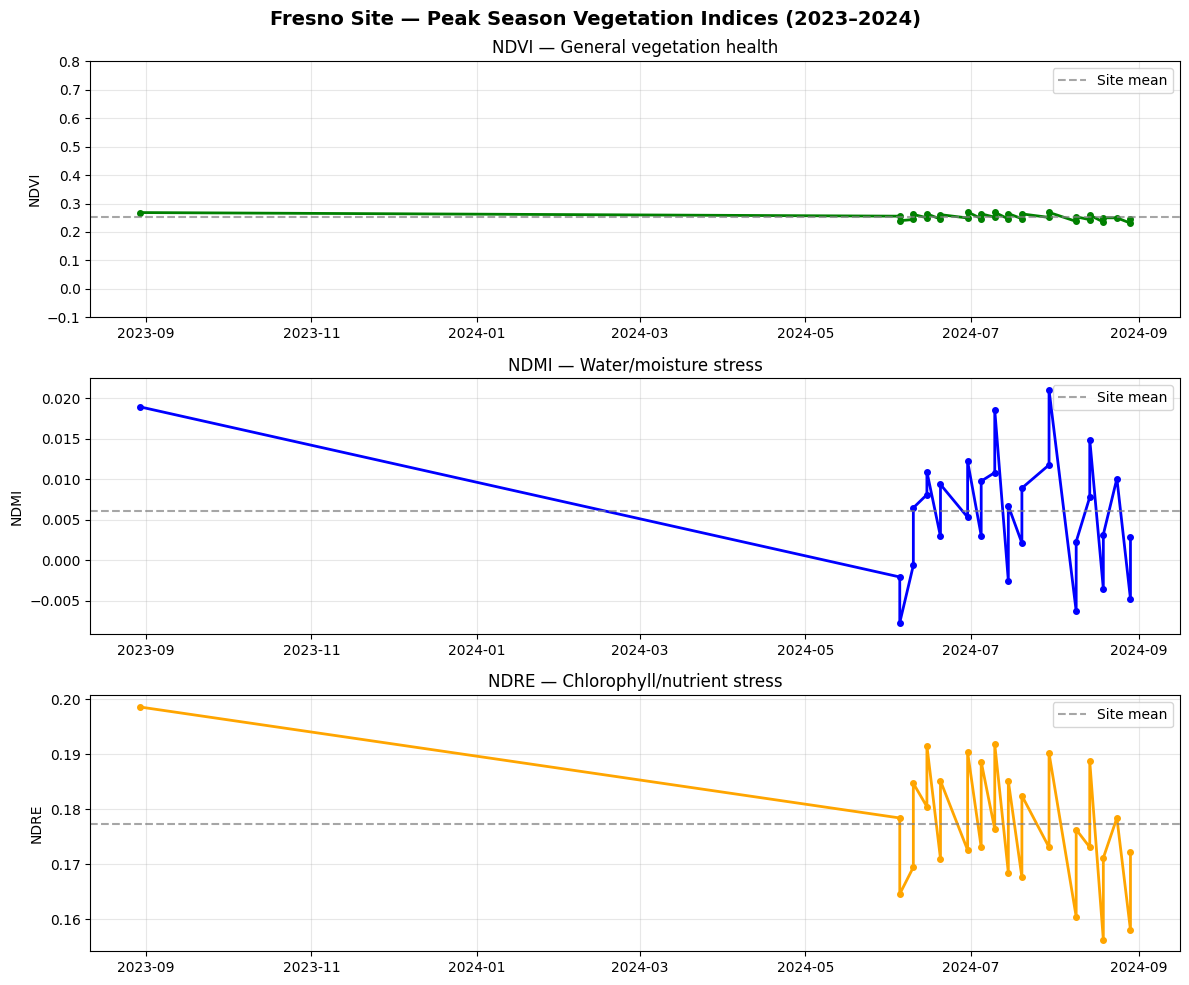

<Figure size 640x480 with 0 Axes>

Chart saved to: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/f3i-dc-2-sbosm/outputs/time_series/fresno_vi_timeseries.png


In [8]:
## # Section 5 — Plot NDVI time series for Fresno

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle("Fresno Site — Peak Season Vegetation Indices (2023–2024)",
             fontsize=14, fontweight='bold')

axes[0].plot(fresno_ts['date'], fresno_ts['NDVI_mean'],
             color='green', linewidth=2, marker='o', markersize=4)
axes[0].axhline(y=fresno_ts['NDVI_mean'].mean(), color='gray',
                linestyle='--', alpha=0.7, label='Site mean')
axes[0].set_ylabel('NDVI')
axes[0].set_title('NDVI — General vegetation health')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 0.8)

axes[1].plot(fresno_ts['date'], fresno_ts['NDMI_mean'],
             color='blue', linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=fresno_ts['NDMI_mean'].mean(), color='gray',
                linestyle='--', alpha=0.7, label='Site mean')
axes[1].set_ylabel('NDMI')
axes[1].set_title('NDMI — Water/moisture stress')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fresno_ts['date'], fresno_ts['NDRE_mean'],
             color='orange', linewidth=2, marker='o', markersize=4)
axes[2].axhline(y=fresno_ts['NDRE_mean'].mean(), color='gray',
                linestyle='--', alpha=0.7, label='Site mean')
axes[2].set_ylabel('NDRE')
axes[2].set_title('NDRE — Chlorophyll/nutrient stress')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_path = TIMESERIES_PATH / "fresno_vi_timeseries.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to: {save_path}")

## Section 6 — Spatial stress zone mapping

We compute a peak-season NDVI composite per year by taking the median 
pixel value across all June-August satellite scenes. We then normalize 
each pixel relative to the orchard mean using z-scores, and average 
the z-scores across all available years to identify persistently 
underperforming zones.

A pixel with a mean z-score below -1.0 across multiple seasons is 
classified as a stressed zone requiring grower attention.

In [9]:
# Section 6 - Compute spatial stress map for one orchard site
# Key fix: fetch fresh items per year to avoid signed URL expiration (HTTP 403).
# Uses search_sentinel2 + compute_indices which are both proven to work.

from collections import defaultdict

def compute_stress_map(site_name, peak_months=PEAK_SEASON_MONTHS,
                       max_scenes_per_year=2):
    """
    Compute multi-year peak-season NDVI stress map.
    Fetches fresh Sentinel-2 items per year to avoid token expiration.
    Z-score normalizes within orchard to find persistently stressed zones.
    """
    yearly_ndvi = {}
    years = [2019, 2020, 2021, 2022, 2023, 2024]

    for year in years:
        # Search fresh for THIS year only - fresh tokens every time
        year_start = f"{year}-06-01"
        year_end   = f"{year}-08-31"

        print(f"\nYear {year}: fetching fresh items...")
        try:
            year_items = search_sentinel2(
                sites[site_name],
                year_start,
                year_end,
                CLOUD_THRESHOLD
            )
        except Exception as e:
            print(f"  Search failed: {e}")
            continue

        if len(year_items) == 0:
            print(f"  No scenes found for {year}")
            continue

        print(f"  Found {len(year_items)} scenes, loading up to {max_scenes_per_year}...")

        ndvi_stack = []
        for item in tqdm(year_items[:max_scenes_per_year]):
            try:
                result = compute_indices(item)
                ndvi = result["NDVI"]

                # Remove extra dimensions
                while ndvi.ndim > 2:
                    ndvi = ndvi[0]

                valid_pct = np.sum(~np.isnan(ndvi)) / ndvi.size
                if valid_pct > 0.001:
                    ndvi_stack.append(ndvi)
                    print(f"  {item.datetime.strftime('%Y-%m-%d')}: "
                          f"valid={valid_pct:.1%}  "
                          f"NDVI={np.nanmean(ndvi):.3f}")
                else:
                    print(f"  {item.datetime.strftime('%Y-%m-%d')}: "
                          f"skipped (valid={valid_pct:.1%})")

            except Exception as e:
                print(f"  Skipped: {str(e)[:60]}")
                continue

        if len(ndvi_stack) == 0:
            print(f"  No valid data for {year}")
            continue

        # Align shapes then median composite
        min_r = min(a.shape[0] for a in ndvi_stack)
        min_c = min(a.shape[1] for a in ndvi_stack)
        ndvi_stack = [a[:min_r, :min_c] for a in ndvi_stack]
        composite = np.nanmedian(np.stack(ndvi_stack), axis=0)
        yearly_ndvi[year] = composite
        print(f"  {year} done: mean NDVI={np.nanmean(composite):.3f}, "
              f"scenes={len(ndvi_stack)}, shape={composite.shape}")

    if len(yearly_ndvi) == 0:
        print("No data processed!")
        return None

    # Align all years to common shape
    min_r = min(v.shape[0] for v in yearly_ndvi.values())
    min_c = min(v.shape[1] for v in yearly_ndvi.values())
    yearly_ndvi = {y: v[:min_r, :min_c] for y, v in yearly_ndvi.items()}

    # Z-score normalize each year within the orchard
    yearly_zscore = {}
    for year, composite in yearly_ndvi.items():
        site_mean = np.nanmean(composite)
        site_std  = np.nanstd(composite)
        z = ((composite - site_mean) / site_std
             if site_std > 0 else np.zeros_like(composite))
        yearly_zscore[year] = z
        print(f"{year} z-score range: {np.nanmin(z):.2f} to {np.nanmax(z):.2f}")

    # Average z-score across years = persistence score
    z_stack = np.stack(list(yearly_zscore.values()), axis=0)
    mean_zscore = np.nanmean(z_stack, axis=0)

    # Classify pixels into stress zones
    stress_map = np.where(
        ~np.isnan(mean_zscore),
        np.where(mean_zscore < -1.0, 2,
        np.where(mean_zscore < -0.5, 1, 0)),
        np.nan
    )

    return {
        "site_name":     site_name,
        "yearly_ndvi":   yearly_ndvi,
        "yearly_zscore": yearly_zscore,
        "mean_zscore":   mean_zscore,
        "stress_map":    stress_map,
        "years":         list(yearly_ndvi.keys())
    }

# Run on Fresno - 2 scenes per year, fresh search each year
print("=" * 55)
print(f"Computing stress map: fresno")
print(f"Strategy: fresh search per year, 2 scenes max")
print("=" * 55)

fresno_stress = compute_stress_map("fresno", max_scenes_per_year=2)

if fresno_stress:
    print(f"\nStress map complete!")
    print(f"Years processed: {fresno_stress['years']}")
    sz = fresno_stress['stress_map']
    total   = np.sum(~np.isnan(sz))
    high    = np.sum(sz == 2)
    mild    = np.sum(sz == 1)
    healthy = np.sum(sz == 0)
    if total > 0:
        print(f"\nZone breakdown:")
        print(f"  High stress:  {high:,} px ({100*high/total:.1f}%)")
        print(f"  Mild stress:  {mild:,} px ({100*mild/total:.1f}%)")
        print(f"  Healthy:      {healthy:,} px ({100*healthy/total:.1f}%)")
        print(f"  Map shape: {sz.shape}")
else:
    print("Failed - check errors above")

Computing stress map: fresno
Strategy: fresh search per year, 2 scenes max

Year 2019: fetching fresh items...
  Found 34 scenes, loading up to 2...


 50%|█████     | 1/2 [00:25<00:25, 25.90s/it]

  2019-08-30: valid=98.4%  NDVI=0.376


100%|██████████| 2/2 [00:51<00:00, 25.79s/it]

  2019-08-30: valid=98.7%  NDVI=0.344


...

 50%|█████     | 1/2 [00:35<00:35, 35.55s/it]

  2024-08-28: valid=99.4%  NDVI=0.244


100%|██████████| 2/2 [01:09<00:00, 34.92s/it]

  2024-08-28: valid=99.7%  NDVI=0.231


  2024 done: mean NDVI=0.237, scenes=2, shape=(5490, 5490)
2019 z-score range: -3.03 to 3.38
2020 z-score range: -3.34 to 3.84
2021 z-score range: -4.81 to 4.08
2022 z-score range: -3.41 to 4.80
2023 z-score range: -5.26 to 2.98
2024 z-score range: -9.35 to 4.69

Stress map complete!
Years processed: [2019, 2020, 2021, 2022, 2023, 2024]

Zone breakdown:
  High stress:  2,965,164 px (9.8%)
  Mild stress:  6,129,596 px (20.3%)
  Healthy:      21,045,321 px (69.8%)
  Map shape: (5490, 5490)


 ## Section 7 - Stress zone map visualization

We visualize the mean z-score map and stress classification for the
Fresno orchard. Red zones indicate pixels that have been persistently
below the orchard average across multiple growing seasons.

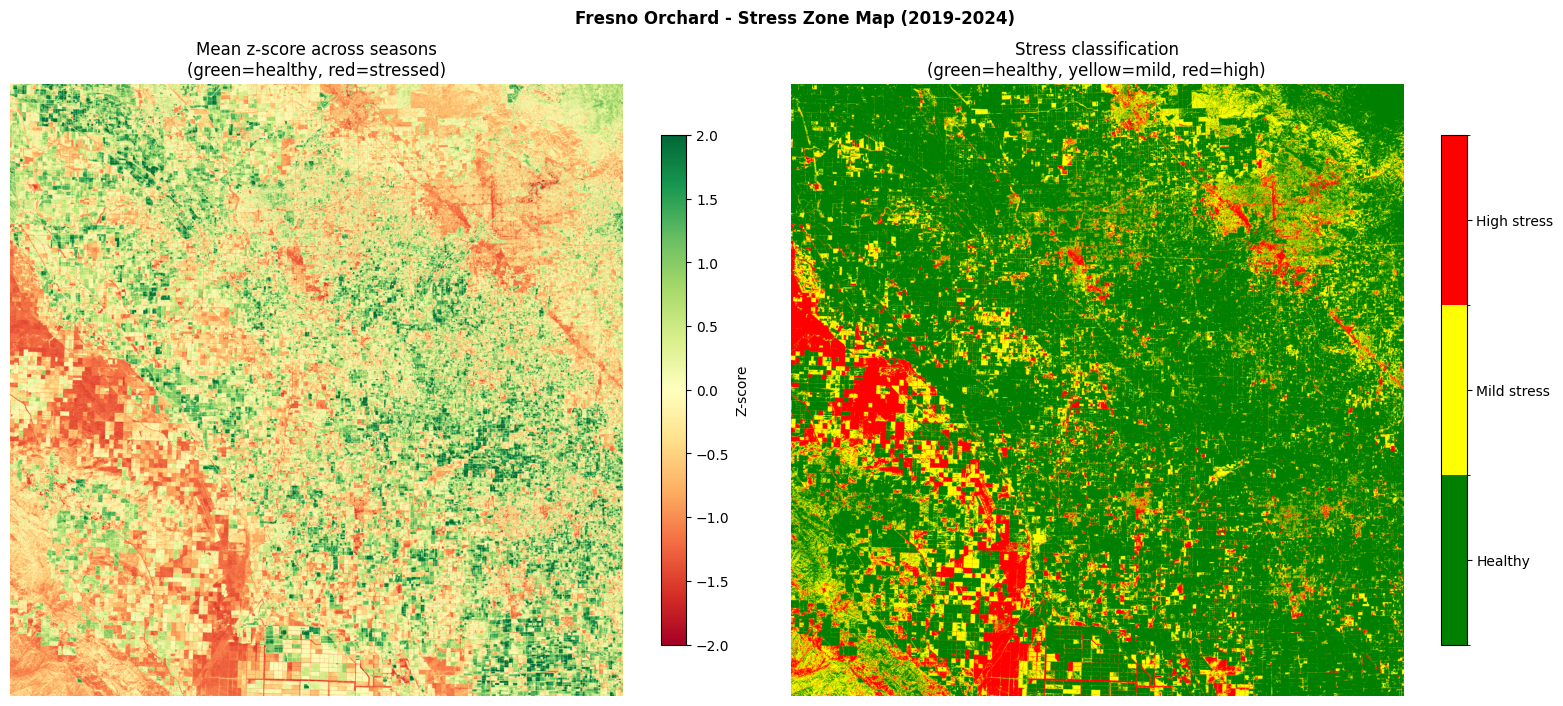

Stress map saved to: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/f3i-dc-2-sbosm/outputs/stress_maps/fresno_stress_map.png

Fresno Orchard Stress Summary (2019-2024):
  Years analyzed: [2019, 2020, 2021, 2022, 2023, 2024]
  High stress: 2,965,164 px (9.8%)
  Mild stress: 6,129,596 px (20.3%)
  Healthy: 21,045,321 px (69.8%)
  Area per pixel: ~400 m² (20m resolution)
  High stress area: ~118,606 hectares


In [10]:
# Section 7 - Plot and save the Fresno stress zone map

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Fresno Orchard - Stress Zone Map (2019-2024)",
             fontsize=12, fontweight='bold', y=1.02)

# Plot 1: Mean z-score heatmap
z = fresno_stress['mean_zscore']
im1 = axes[0].imshow(z, cmap='RdYlGn', vmin=-2, vmax=2)
axes[0].set_title('Mean z-score across seasons\n(green=healthy, red=stressed)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Z-score', shrink=0.8)

# Plot 2: Classified stress zones
stress = fresno_stress['stress_map']
cmap = plt.cm.colors.ListedColormap(['green', 'yellow', 'red'])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
im2 = axes[1].imshow(stress, cmap=cmap, norm=norm)
axes[1].set_title('Stress classification\n(green=healthy, yellow=mild, red=high)')
axes[1].axis('off')
cbar = plt.colorbar(im2, ax=axes[1], shrink=0.8)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Healthy', 'Mild stress', 'High stress'])

plt.tight_layout()

# Save map
save_path = MAPS_PATH / "fresno_stress_map.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Stress map saved to: {save_path}")

# Print summary for report
print(f"\nFresno Orchard Stress Summary (2019-2024):")
print(f"  Years analyzed: {fresno_stress['years']}")
total = np.sum(~np.isnan(stress))
for label, val in [("High stress", 2), ("Mild stress", 1), ("Healthy", 0)]:
    n = np.sum(stress == val)
    print(f"  {label}: {n:,} px ({100*n/total:.1f}%)")
print(f"  Area per pixel: ~400 m² (20m resolution)")
print(f"  High stress area: ~{int(np.sum(stress==2)*400/10000):,} hectares")